<a href="https://colab.research.google.com/github/Teja3993/Deep-Learning-Lab-exercises/blob/main/Experiment_5_Simple_2D_CNN_Demonstration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# 1. Load the Dataset
# MNIST is built into Keras, making it perfect for demonstrations.
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 2. Preprocess the Data
# Normalize pixel values to be between 0 and 1 (they start as 0-255)
X_train = X_train / 255.0
X_test = X_test / 255.0

# CNNs expect a color channel dimension.
# Our images are grayscale, so we add a "1" to the end: (Samples, 28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# 3. Build the CNN Model
model = Sequential()

# Feature Extraction Section (The "Convolutional" part)
# Conv2D: Scans the image with 32 small 3x3 grids (filters) to find patterns like edges.
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

# MaxPooling2D: Shrinks the image size (takes the max value in a 2x2 grid),
# keeping the most important features while reducing computation.
model.add(MaxPooling2D(pool_size=(2, 2)))

# Add a second Conv2D and Pooling layer for deeper pattern recognition
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Classification Section
# Flatten: Converts the 2D feature maps into a flat 1D array
model.add(Flatten())

# Dense: Standard neural network layer to learn the relationships between features
model.add(Dense(64, activation='relu'))

# Output layer: 10 neurons for the 10 possible digits (0-9). 'softmax' gives probabilities.
model.add(Dense(10, activation='softmax'))

# 4. Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train the Model
print("Training the CNN...")
# We use just 3 epochs for a quick demonstration
model.fit(X_train, y_train, epochs=3, validation_split=0.1)

# 6. Evaluate the Model
print("\nEvaluating on Test Data...")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc:.4f}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training the CNN...
Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 54s 31ms/step - accuracy: 0.9511 - loss: 0.1612 - val_accuracy: 0.9817 - val_loss: 0.0647
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 49s 29ms/step - accuracy: 0.9837 - loss: 0.0524 - val_accuracy: 0.9870 - val_loss: 0.0411
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 84s 30ms/step - accuracy: 0.9889 - loss: 0.0357 - val_accuracy: 0.9910 - val_loss: 0.0320

Evaluating on Test Data...
313/313 - 3s - 8ms/step - accuracy: 0.9898 - loss: 0.0300

Test Accuracy: 0.9898


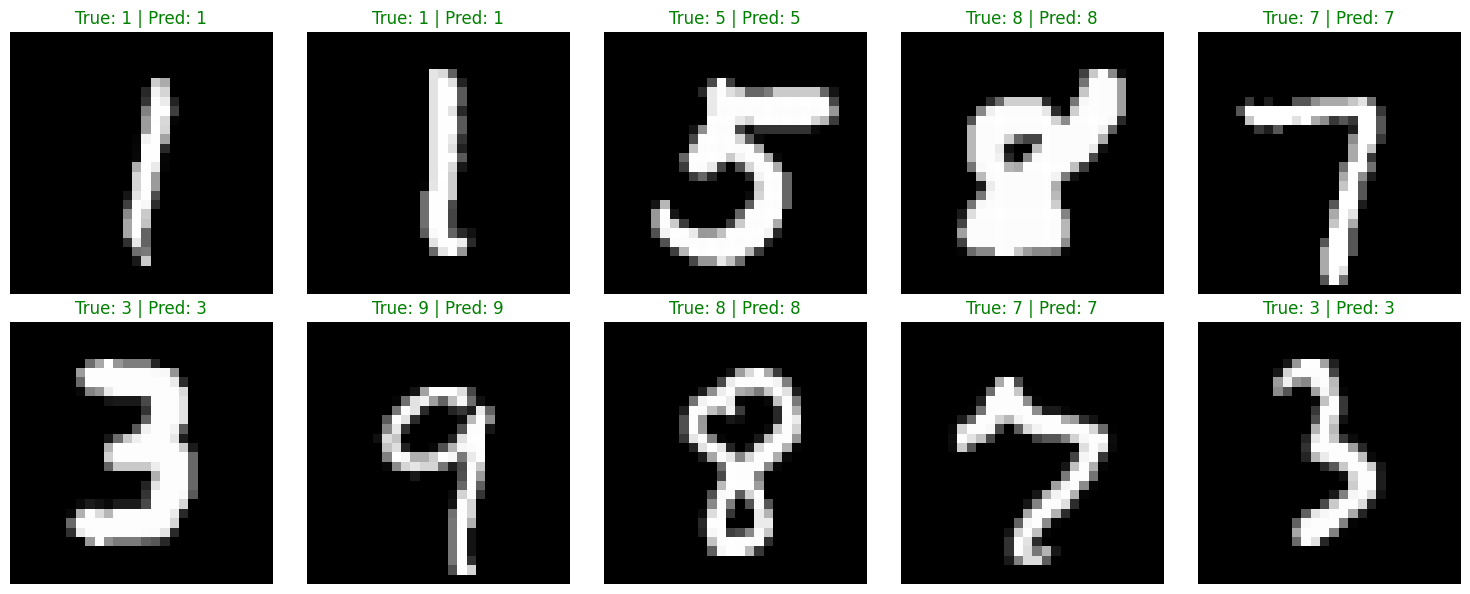

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Select 10 random images from the test set
num_images = 10
random_indices = np.random.choice(len(X_test), num_images, replace=False)

# 2. Set up a figure for plotting
plt.figure(figsize=(15, 6))

for i, idx in enumerate(random_indices):
    test_img = X_test[idx]
    true_label = y_test[idx]

    # 3. Make a prediction
    # model.predict expects a batch, so we temporarily reshape from (28, 28, 1) to (1, 28, 28, 1)
    prediction = model.predict(test_img.reshape(1, 28, 28, 1), verbose=0)
    predicted_label = np.argmax(prediction)

    # 4. Plot the image
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(test_img.reshape(28, 28), cmap='gray') # Reshape back to 2D for matplotlib

    # Color the text Green if the AI got it right, Red if it got it wrong
    text_color = 'green' if predicted_label == true_label else 'red'
    plt.title(f"True: {true_label} | Pred: {predicted_label}", color=text_color, fontsize=12)
    plt.axis('off')

# 5. Display the final grid
plt.tight_layout()
plt.show()